# ResNet-20 on CIFAR-100

This notebook sets up CIFAR-100, defines a CIFAR-adapted ResNet-20 (num_classes=100), and provides a training demo and evaluation cells. Adjust parameters in the "Run Demo" cell to run a full 100-epoch training. 

How to use:
- Run cells top-to-bottom.
- To run a quick test, set demo epochs to 5. For a full run set epochs=100 and run the training cell.

Files produced:
- models/resnet20_cifar100.pth (when you call the save checkpoint cell)

Note: This notebook is designed for a single-GPU or CPU. For large runs, run on a GPU-enabled runtime.

In [2]:
# Imports and device / seed setup
import os
import time
import logging
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Logging and device
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Create folders
Path('./models').mkdir(parents=True, exist_ok=True)
Path('./data').mkdir(parents=True, exist_ok=True)


Using device: cuda


In [3]:
# CIFAR-100 transforms and dataloaders (download dataset)
from torchvision.datasets import CIFAR100

classes_fine = [
    # CIFAR-100 fine labels are available via dataset.classes after download; we'll print them
]

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
])


def setup_cifar100_data(batch_size=128, data_dir='./data'):
    """Download CIFAR-100 and return train/test dataloaders"""
    logger.info('Setting up CIFAR-100 data loaders...')
    train_dataset = CIFAR100(root=data_dir, train=True, download=True, transform=transform_train)
    test_dataset = CIFAR100(root=data_dir, train=False, download=True, transform=transform_test)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    # expose fine class names for visualization
    classes_fine = train_dataset.classes
    logger.info(f'Train batches: {len(train_loader)}, Test batches: {len(test_loader)}')
    return train_loader, test_loader, classes_fine

# Create loaders
train_loader, test_loader, classes_fine = setup_cifar100_data(batch_size=128, data_dir='./data')

print(f"Training samples: {len(train_loader.dataset)}")
print(f"Test samples: {len(test_loader.dataset)}")
print(f"Number of classes: {len(classes_fine)}")


2025-11-02 02:03:39,136 - INFO - Setting up CIFAR-100 data loaders...
2025-11-02 02:03:40,484 - INFO - Train batches: 391, Test batches: 79
2025-11-02 02:03:40,484 - INFO - Train batches: 391, Test batches: 79


Training samples: 50000
Test samples: 10000
Number of classes: 100


In [ ]:
# Visualize sample images from CIFAR-100
import matplotlib.pyplot as plt
import torch

def show_sample_images(dataloader, class_names, num_samples=8):
    data_iter = iter(dataloader)
    images, labels = next(data_iter)

    plt.figure(figsize=(12, 6))
    for i in range(num_samples):
        plt.subplot(2, 4, i + 1)
        img = images[i]
        # denormalize
        mean = torch.tensor((0.5071, 0.4867, 0.4408)).view(3,1,1)
        std = torch.tensor((0.2675, 0.2565, 0.2761)).view(3,1,1)
        img = img * std + mean
        img = torch.clamp(img, 0, 1)
        plt.imshow(img.permute(1,2,0).numpy())
        plt.title(class_names[labels[i]])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Display samples
show_sample_images(train_loader, classes_fine, num_samples=8)


In [4]:
# ResNet-20 definition adapted for CIFAR-100 (num_classes=100)
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * planes)
            )
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class ResNet20(nn.Module):
    def __init__(self, block=BasicBlock, num_blocks=[3,3,3], num_classes=100):
        super(ResNet20, self).__init__()
        self.in_planes = 16
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.layer1 = self._make_layer(block, 16, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 32, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 64, num_blocks[2], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.linear = nn.Linear(64 * block.expansion, num_classes)
        self._initialize_weights()
    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out


In [5]:
# Model instantiation, parameter count and forward-pass sanity check
model = ResNet20(num_classes=100).to(device)

def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

total_params, trainable_params = count_parameters(model)
print(f"Model: ResNet-20 (CIFAR-100)")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Forward pass sanity
test_input = torch.randn(1, 3, 32, 32).to(device)
with torch.no_grad():
    test_output = model(test_input)
print(f"Test forward output shape: {test_output.shape}")


Model: ResNet-20 (CIFAR-100)
Total parameters: 278,324
Trainable parameters: 278,324
Test forward output shape: torch.Size([1, 100])
Test forward output shape: torch.Size([1, 100])


In [6]:
# Training utilities: loss, optimizer, scheduler, metric trackers
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[60,80], gamma=0.1)

train_losses = []
train_accs = []
test_accs = []

# accuracy helper
def accuracy(output, target):
    preds = output.argmax(dim=1)
    correct = preds.eq(target).sum().item()
    return 100.0 * correct / target.size(0)


In [7]:
# Training loop cell (quick demo / short run)

def train_epoch(model, loader, optimizer, criterion, device, max_batches=None):
    model.train()
    running_loss = 0.0
    running_acc = 0.0
    n = 0
    pbar = tqdm(loader, desc='Train', leave=False)
    for batch_idx, (data, target) in enumerate(pbar):
        if max_batches and batch_idx >= max_batches:
            break
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * data.size(0)
        running_acc += (output.argmax(dim=1) == target).sum().item()
        n += data.size(0)
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    avg_loss = running_loss / n
    avg_acc = 100.0 * running_acc / n
    return avg_loss, avg_acc


def test_epoch(model, loader, criterion, device, max_batches=None):
    model.eval()
    running_loss = 0.0
    running_acc = 0.0
    n = 0
    with torch.no_grad():
        pbar = tqdm(loader, desc='Test', leave=False)
        for batch_idx, (data, target) in enumerate(pbar):
            if max_batches and batch_idx >= max_batches:
                break
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            running_loss += loss.item() * data.size(0)
            running_acc += (output.argmax(dim=1) == target).sum().item()
            n += data.size(0)
    avg_loss = running_loss / n
    avg_acc = 100.0 * running_acc / n
    return avg_loss, avg_acc


def train_demo(epochs=5, max_batches_per_epoch=None):
    print(f"Starting demo training for {epochs} epochs (max_batches_per_epoch={max_batches_per_epoch})")
    for epoch in range(epochs):
        start = time.time()
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device, max_batches=max_batches_per_epoch)
        test_loss, test_acc = test_epoch(model, test_loader, criterion, device, max_batches=max_batches_per_epoch)
        scheduler.step()

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)

        elapsed = time.time() - start
        logger.info(f"Epoch {epoch:3d}: Train loss={train_loss:.4f}, Train acc={train_acc:.2f}%, Test acc={test_acc:.2f}%, Time={elapsed:.1f}s")

    print('Demo training finished')

# Example: run a quick demo (5 epochs, limit batches to 200 for speed)
# train_demo(epochs=5, max_batches_per_epoch=200)


In [11]:
# Evaluation and per-class accuracy

def evaluate_model(model, loader, device, max_batches=None):
    loss, acc = test_epoch(model, loader, criterion, device, max_batches=max_batches)
    print(f"Evaluation -> Loss: {loss:.4f}, Accuracy: {acc:.2f}%")
    return loss, acc


def test_per_class_accuracy(model, loader, class_names, device, max_batches=None):
    model.eval()
    class_correct = [0 for _ in range(len(class_names))]
    class_total = [0 for _ in range(len(class_names))]
    with torch.no_grad():
        for batch_idx, (data, target) in enumerate(loader):
            if max_batches and batch_idx >= max_batches:
                break
            data, target = data.to(device), target.to(device)
            output = model(data)
            preds = output.argmax(dim=1)
            for i in range(target.size(0)):
                label = target[i].item()
                class_correct[label] += int(preds[i] == target[i])
                class_total[label] += 1
    per_class = {}
    for i, name in enumerate(class_names):
        acc = 100.0 * class_correct[i] / class_total[i] if class_total[i] > 0 else 0.0
        per_class[name] = acc
    # print a summary for top 10 classes by accuracy
    sorted_items = sorted(per_class.items(), key=lambda x: x[1], reverse=True)
    print('Top 10 classes by accuracy:')
    for name, a in sorted_items[:10]:
        print(f"  {name:20s}: {a:.2f}%")
    return per_class

# Example usage (run after training):
# evaluate_model(model, test_loader, device)
# test_per_class_accuracy(model, test_loader, classes_fine, device)


In [8]:
# Save checkpoint and load helper

def save_checkpoint(path, model, optimizer, scheduler, epoch, metadata=None):
    state = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'metadata': metadata or {}
    }
    torch.save(state, path)
    print(f"Saved checkpoint to {path}")


def load_checkpoint(path, model, optimizer=None, scheduler=None, device='cpu'):
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    if optimizer and 'optimizer_state_dict' in checkpoint:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    if scheduler and 'scheduler_state_dict' in checkpoint:
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    print(f"Loaded checkpoint from {path} (epoch {checkpoint.get('epoch')})")
    return checkpoint

# Example save path: './models/resnet20_cifar100.pth'


In [9]:
# Run full 300-epoch training (long-running)
# Cell inserted by assistant. This will start the full training run and save a final checkpoint.
epochs = 300
save_path = './models/resnet20_cifar100_epoch300.pth'
print(f"Starting full training for {epochs} epochs on device: {device}")
# Run the training demo (this uses train_demo defined earlier in the notebook)
train_demo(epochs=epochs)
# Save a checkpoint after training
save_checkpoint(save_path, model, optimizer, scheduler, epoch=epochs, metadata={'note':'300 epoch run'})
print("Training complete. Checkpoint saved to", save_path)


Starting full training for 300 epochs on device: cuda
Starting demo training for 300 epochs (max_batches_per_epoch=None)


2025-11-02 02:04:27,366 - INFO - Epoch   0: Train loss=4.0198, Train acc=7.36%, Test acc=11.39%, Time=11.3s
2025-11-02 02:04:38,327 - INFO - Epoch   1: Train loss=3.4653, Train acc=15.79%, Test acc=18.77%, Time=11.0s
2025-11-02 02:04:49,334 - INFO - Epoch   2: Train loss=3.0106, Train acc=24.33%, Test acc=26.35%, Time=11.0s
2025-11-02 02:05:00,348 - INFO - Epoch   3: Train loss=2.6753, Train acc=30.53%, Test acc=32.86%, Time=11.0s
2025-11-02 02:05:11,303 - INFO - Epoch   4: Train loss=2.4212, Train acc=36.08%, Test acc=34.33%, Time=11.0s
2025-11-02 02:05:22,292 - INFO - Epoch   5: Train loss=2.2226, Train acc=40.34%, Test acc=41.53%, Time=11.0s
2025-11-02 02:05:33,210 - INFO - Epoch   6: Train loss=2.0801, Train acc=43.48%, Test acc=38.74%, Time=10.9s
2025-11-02 02:05:44,165 - INFO - Epoch   7: Train loss=1.9615, Train acc=46.17%, Test acc=39.19%, Time=11.0s
2025-11-02 02:05:55,178 - INFO - Epoch   8: Train loss=1.8765, Train acc=48.32%, Test acc=43.73%, Time=11.0s
2025-11-02 02:06:06,

Demo training finished
Saved checkpoint to ./models/resnet20_cifar100_epoch300.pth
Training complete. Checkpoint saved to ./models/resnet20_cifar100_epoch300.pth


In [12]:
# Evaluation cell: load checkpoint (final) and compute top-1 / top-5 and per-class accuracy
checkpoint_path = './models/resnet20_cifar100_epoch300.pth'
print('Loading checkpoint:', checkpoint_path)
load_checkpoint(checkpoint_path, model, optimizer=None, scheduler=None, device=device)

# Compute basic test metrics
loss, acc = test_epoch(model, test_loader, criterion, device)
print(f"Test loss: {loss:.4f}, Top-1 accuracy: {acc:.2f}%")

# Compute Top-1 and Top-5 accuracy explicitly
import torch
model.eval()
correct1 = 0
correct5 = 0
total = 0
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        outputs = model(data)
        _, pred = outputs.topk(5, 1, True, True)
        pred = pred.t()
        correct = pred.eq(target.view(1, -1).expand_as(pred))
        correct1 += correct[:1].reshape(-1).float().sum(0, keepdim=True).item()
        correct5 += correct[:5].reshape(-1).float().sum(0, keepdim=True).item()
        total += target.size(0)

print(f"Computed Top-1: {100.0 * correct1 / total:.2f}% | Top-5: {100.0 * correct5 / total:.2f}%")

# Per-class accuracy summary (top-10 and bottom-10 classes)
per_class = test_per_class_accuracy(model, test_loader, classes_fine, device)
sorted_items = sorted(per_class.items(), key=lambda x: x[1], reverse=True)
print('\nTop 10 classes by accuracy:')
for name, a in sorted_items[:10]:
    print(f"  {name:20s}: {a:.2f}%")
print('\nBottom 10 classes by accuracy:')
for name, a in sorted_items[-10:]:
    print(f"  {name:20s}: {a:.2f}%")

# Quick confusion-matrix-like check for a few classes (optional)
try:
    from sklearn.metrics import confusion_matrix
    import numpy as np
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for data, target in test_loader:
            data = data.to(device)
            outputs = model(data)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds.tolist())
            all_targets.extend(target.numpy().tolist())
    cm = confusion_matrix(all_targets, all_preds)
    print('\nConfusion matrix shape:', cm.shape)
except Exception as e:
    print('sklearn not available or error computing confusion matrix:', e)


Loading checkpoint: ./models/resnet20_cifar100_epoch300.pth
Loaded checkpoint from ./models/resnet20_cifar100_epoch300.pth (epoch 300)


Test loss: 1.4189, Top-1 accuracy: 66.79%


Computed Top-1: 66.79% | Top-5: 89.89%
Top 10 classes by accuracy:
  road                : 93.00%
  motorcycle          : 92.00%
  skunk               : 88.00%
  apple               : 87.00%
  orange              : 87.00%
  wardrobe            : 87.00%
  chair               : 86.00%
  lawn_mower          : 86.00%
  keyboard            : 85.00%
  sunflower           : 85.00%

Top 10 classes by accuracy:
  road                : 93.00%
  motorcycle          : 92.00%
  skunk               : 88.00%
  apple               : 87.00%
  orange              : 87.00%
  wardrobe            : 87.00%
  chair               : 86.00%
  lawn_mower          : 86.00%
  keyboard            : 85.00%
  sunflower           : 85.00%

Bottom 10 classes by accuracy:
  turtle              : 50.00%
  possum              : 49.00%
  rabbit              : 46.00%
  boy                 : 44.00%
  shrew               : 44.00%
  girl                : 42.00%
  bear                : 41.00%
  seal                : 40.00%
  li

In [16]:
# --- MAP integration (adapted from MAP_Implementation.ipynb) ---
# This cell defines MAPConv2d, MAPPruner, MAPTrainer adapted for CIFAR-100
import torch
import torch.nn.functional as F

class MAPConv2d(nn.Module):
    """Conv2d layer with MAP attention mechanism (adapted)"""
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, bias=True):
        super(MAPConv2d, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=bias)
        self.alpha = nn.Parameter(torch.ones(1))
        self.register_buffer('mask', torch.ones_like(self.conv.weight))
        self.register_buffer('magnitude_history', torch.zeros_like(self.conv.weight))
        self.register_buffer('update_count', torch.zeros(1))

    def forward(self, x):
        magnitude = torch.abs(self.conv.weight)
        attention = torch.sigmoid(self.alpha * magnitude)
        effective_weight = self.conv.weight * attention * self.mask
        with torch.no_grad():
            self.magnitude_history = 0.9 * self.magnitude_history + 0.1 * magnitude
        return F.conv2d(x, effective_weight, self.conv.bias, self.conv.stride, self.conv.padding)

    def update_mask(self, sparsity_level):
        with torch.no_grad():
            magnitude = torch.abs(self.conv.weight)
            alpha_device = self.alpha.to(magnitude.device)
            attention = torch.sigmoid(alpha_device * magnitude)
            importance = magnitude * attention
            flat_importance = importance.view(-1)
            k = int(sparsity_level * flat_importance.numel())
            if k > 0:
                threshold = torch.kthvalue(flat_importance, k)[0]
                self.mask = (importance > threshold).float()
            else:
                self.mask = torch.ones_like(importance)
            self.update_count += 1

class MAPPruner:
    def __init__(self, model, target_sparsity=0.9, start_epoch=0, end_epoch=300):
        self.model = model
        self.target_sparsity = target_sparsity
        self.start_epoch = start_epoch
        self.end_epoch = end_epoch
        self._convert_to_map_layers()
        self.sparsity_history = []

    def _convert_to_map_layers(self):
        def replace_conv2d(module):
            for name, child in list(module.named_children()):
                if isinstance(child, nn.Conv2d):
                    map_conv = MAPConv2d(
                        child.in_channels, child.out_channels, child.kernel_size,
                        child.stride, child.padding, child.bias is not None
                    )
                    map_conv.conv.weight.data = child.weight.data.clone()
                    if child.bias is not None:
                        map_conv.conv.bias.data = child.bias.data.clone()
                    map_conv = map_conv.to(next(self.model.parameters()).device)
                    setattr(module, name, map_conv)
                else:
                    replace_conv2d(child)
        replace_conv2d(self.model)
        logger.info("Converted Conv2d layers to MAPConv2d layers")

    def get_map_layers(self):
        map_layers = []
        for module in self.model.modules():
            if isinstance(module, MAPConv2d):
                map_layers.append(module)
        return map_layers

    def calculate_current_sparsity(self):
        total_params = 0
        zero_params = 0
        for layer in self.get_map_layers():
            mask = layer.mask
            total_params += mask.numel()
            zero_params += (mask == 0).sum().item()
        sparsity = zero_params / total_params if total_params > 0 else 0
        return sparsity

    def get_target_sparsity_for_epoch(self, epoch):
        if epoch < self.start_epoch:
            return 0.0
        elif epoch >= self.end_epoch:
            return self.target_sparsity
        else:
            progress = (epoch - self.start_epoch) / (self.end_epoch - self.start_epoch)
            return self.target_sparsity * (1 - (1 - progress) ** 3)

    def update_masks(self, epoch):
        target_sparsity = self.get_target_sparsity_for_epoch(epoch)
        for layer in self.get_map_layers():
            layer.update_mask(target_sparsity)
        current_sparsity = self.calculate_current_sparsity()
        self.sparsity_history.append(current_sparsity)
        return current_sparsity

class MAPTrainer:
    def __init__(self, model, pruner, train_loader, test_loader, device):
        self.model = model
        self.pruner = pruner
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.device = device
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.SGD(model.parameters(), lr=0.2, momentum=0.9, weight_decay=1e-4)
        self.scheduler = optim.lr_scheduler.MultiStepLR(self.optimizer, milestones=[150, 225], gamma=0.1)
        self.train_losses = []
        self.train_accuracies = []
        self.test_accuracies = []
        self.sparsity_levels = []
        self.best_acc = 0.0
        self.best_model_state = None
        self.exploration_epochs = 150
        logger.info(f"MAPTrainer initialized (target sparsity={pruner.target_sparsity})")

    def get_current_phase(self, epoch):
        return "Exploration" if epoch < self.exploration_epochs else "Exploitation"

    def train_epoch(self, epoch):
        self.model.train()
        total_loss = 0.0
        correct = 0
        total = 0
        mask_update_freq = 16
        pbar = tqdm(self.train_loader, desc=f'Epoch {epoch}', leave=False)
        for batch_idx, (data, target) in enumerate(pbar):
            data, target = data.to(self.device), target.to(self.device)
            if epoch < self.exploration_epochs and batch_idx % mask_update_freq == 0:
                current_sparsity = self.pruner.update_masks(epoch)
            self.optimizer.zero_grad()
            output = self.model(data)
            loss = self.criterion(output, target)
            loss.backward()
            self.optimizer.step()
            total_loss += loss.item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            total += target.size(0)
            current_acc = 100.0 * correct / total
            pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{current_acc:.1f}%'})
        avg_loss = total_loss / len(self.train_loader)
        accuracy = 100.0 * correct / total
        return avg_loss, accuracy

    def test_epoch(self):
        self.model.eval()
        test_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for data, target in self.test_loader:
                data, target = data.to(self.device), target.to(self.device)
                output = self.model(data)
                test_loss += self.criterion(output, target).item()
                pred = output.argmax(dim=1, keepdim=True)
                correct += pred.eq(target.view_as(pred)).sum().item()
                total += target.size(0)
        avg_loss = test_loss / len(self.test_loader)
        accuracy = 100.0 * correct / total
        return avg_loss, accuracy

    def save_checkpoint(self, epoch, accuracy):
        if accuracy > self.best_acc:
            self.best_acc = accuracy
            self.best_model_state = self.model.state_dict().copy()
            logger.info(f"New best model saved with accuracy: {accuracy:.2f}%")

    def train(self, epochs):
        logger.info(f"Starting MAP training for {epochs} epochs")
        for epoch in range(epochs):
            start_time = time.time()
            train_loss, train_acc = self.train_epoch(epoch)
            test_loss, test_acc = self.test_epoch()
            self.scheduler.step()
            current_sparsity = self.pruner.calculate_current_sparsity()
            phase = self.get_current_phase(epoch)
            self.save_checkpoint(epoch, test_acc)
            self.train_losses.append(train_loss)
            self.train_accuracies.append(train_acc)
            self.test_accuracies.append(test_acc)
            self.sparsity_levels.append(current_sparsity)
            epoch_time = time.time() - start_time
            logger.info(
                f"Epoch {epoch:3d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:6.2f}% | Test Acc: {test_acc:6.2f}% | Sparsity: {current_sparsity:6.3f} | Phase: {phase} | Time: {epoch_time:.1f}s"
            )
            if epoch > 20 and len(set(self.test_accuracies[-5:])) == 1:
                logger.info("Early convergence detected")
                break

    def plot_training_progress(self):
        epochs = range(len(self.train_losses))
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
        ax1.plot(epochs, self.train_losses, label='Train Loss')
        ax1.set_title('Training Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.legend()
        ax1.grid(True)
        ax2.plot(epochs, self.train_accuracies, label='Train Acc', alpha=0.7)
        ax2.plot(epochs, self.test_accuracies, label='Test Acc')
        ax2.set_title('Accuracy Progress')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy (%)')
        ax2.legend()
        ax2.grid(True)
        ax3.plot(epochs, self.sparsity_levels, label='Sparsity', color='red')
        ax3.set_title('Sparsity Level')
        ax3.set_xlabel('Epoch')
        ax3.set_ylabel('Sparsity')
        ax3.legend()
        ax3.grid(True)
        lrs = [self.scheduler.get_last_lr()[0] for _ in epochs]
        ax4.plot(epochs, lrs, label='Learning Rate', color='orange')
        ax4.set_title('Learning Rate Schedule')
        ax4.set_xlabel('Epoch')
        ax4.set_ylabel('Learning Rate')
        ax4.set_yscale('log')
        ax4.legend()
        ax4.grid(True)
        plt.tight_layout()
        plt.show()

# Instantiate MAP pruner and trainer for the CIFAR-100 model
model = model.to(device)
map_pruner = MAPPruner(model, target_sparsity=0.9, start_epoch=0, end_epoch=300)
map_trainer = MAPTrainer(model, map_pruner, train_loader, test_loader, device)
print("MAP integration complete. Running a short 10-epoch smoke test...")
# Short SMOKE test to ensure flow works (adjust epochs small to save time)
map_trainer.train(epochs=10)
print("Smoke test finished. Best test accuracy (so far):", map_trainer.best_acc)


2025-11-02 10:41:00,585 - INFO - Converted Conv2d layers to MAPConv2d layers
2025-11-02 10:41:00,586 - INFO - MAPTrainer initialized (target sparsity=0.9)
2025-11-02 10:41:00,586 - INFO - Starting MAP training for 10 epochs
2025-11-02 10:41:00,586 - INFO - MAPTrainer initialized (target sparsity=0.9)
2025-11-02 10:41:00,586 - INFO - Starting MAP training for 10 epochs


MAP integration complete. Running a short 10-epoch smoke test...


2025-11-02 10:41:11,925 - INFO - New best model saved with accuracy: 12.66%      
2025-11-02 10:41:11,926 - INFO - Epoch   0 | Train Loss: 4.0350 | Train Acc:   7.39% | Test Acc:  12.66% | Sparsity:  0.000 | Phase: Exploration | Time: 11.3s
Epoch 1:   0%|          | 0/391 [00:00<?, ?it/s]2025-11-02 10:41:11,925 - INFO - New best model saved with accuracy: 12.66%
2025-11-02 10:41:11,926 - INFO - Epoch   0 | Train Loss: 4.0350 | Train Acc:   7.39% | Test Acc:  12.66% | Sparsity:  0.000 | Phase: Exploration | Time: 11.3s
2025-11-02 10:41:23,288 - INFO - New best model saved with accuracy: 19.88%       
2025-11-02 10:41:23,289 - INFO - Epoch   1 | Train Loss: 3.4210 | Train Acc:  16.89% | Test Acc:  19.88% | Sparsity:  0.009 | Phase: Exploration | Time: 11.4s
Epoch 2:   0%|          | 0/391 [00:00<?, ?it/s]2025-11-02 10:41:23,288 - INFO - New best model saved with accuracy: 19.88%
2025-11-02 10:41:23,289 - INFO - Epoch   1 | Train Loss: 3.4210 | Train Acc:  16.89% | Test Acc:  19.88% | Spa

Smoke test finished. Best test accuracy (so far): 46.58


2025-11-02 10:47:52,298 - INFO - Converted Conv2d layers to MAPConv2d layers
2025-11-02 10:47:52,299 - INFO - MAPTrainer initialized (target sparsity=0.9)
2025-11-02 10:47:52,299 - INFO - Starting MAP training for 300 epochs
2025-11-02 10:47:52,299 - INFO - MAPTrainer initialized (target sparsity=0.9)
2025-11-02 10:47:52,299 - INFO - Starting MAP training for 300 epochs


Starting full MAP training (300 epochs) — CIFAR-100
This will take a long time on a single GPU. Consider enabling checkpointing or running for fewer epochs first.


2025-11-02 10:48:03,598 - INFO - New best model saved with accuracy: 11.58%      
2025-11-02 10:48:03,598 - INFO - Epoch   0 | Train Loss: 4.0492 | Train Acc:   7.09% | Test Acc:  11.58% | Sparsity:  0.000 | Phase: Exploration | Time: 11.3s
Epoch 1:   0%|          | 0/391 [00:00<?, ?it/s]2025-11-02 10:48:03,598 - INFO - New best model saved with accuracy: 11.58%
2025-11-02 10:48:03,598 - INFO - Epoch   0 | Train Loss: 4.0492 | Train Acc:   7.09% | Test Acc:  11.58% | Sparsity:  0.000 | Phase: Exploration | Time: 11.3s
2025-11-02 10:48:14,994 - INFO - New best model saved with accuracy: 15.42%       
2025-11-02 10:48:14,995 - INFO - Epoch   1 | Train Loss: 3.5051 | Train Acc:  15.27% | Test Acc:  15.42% | Sparsity:  0.009 | Phase: Exploration | Time: 11.4s
Epoch 2:   0%|          | 0/391 [00:00<?, ?it/s]2025-11-02 10:48:14,994 - INFO - New best model saved with accuracy: 15.42%
2025-11-02 10:48:14,995 - INFO - Epoch   1 | Train Loss: 3.5051 | Train Acc:  15.27% | Test Acc:  15.42% | Spa


Full training completed!
Best test accuracy: 65.54%
Final sparsity: 0.785


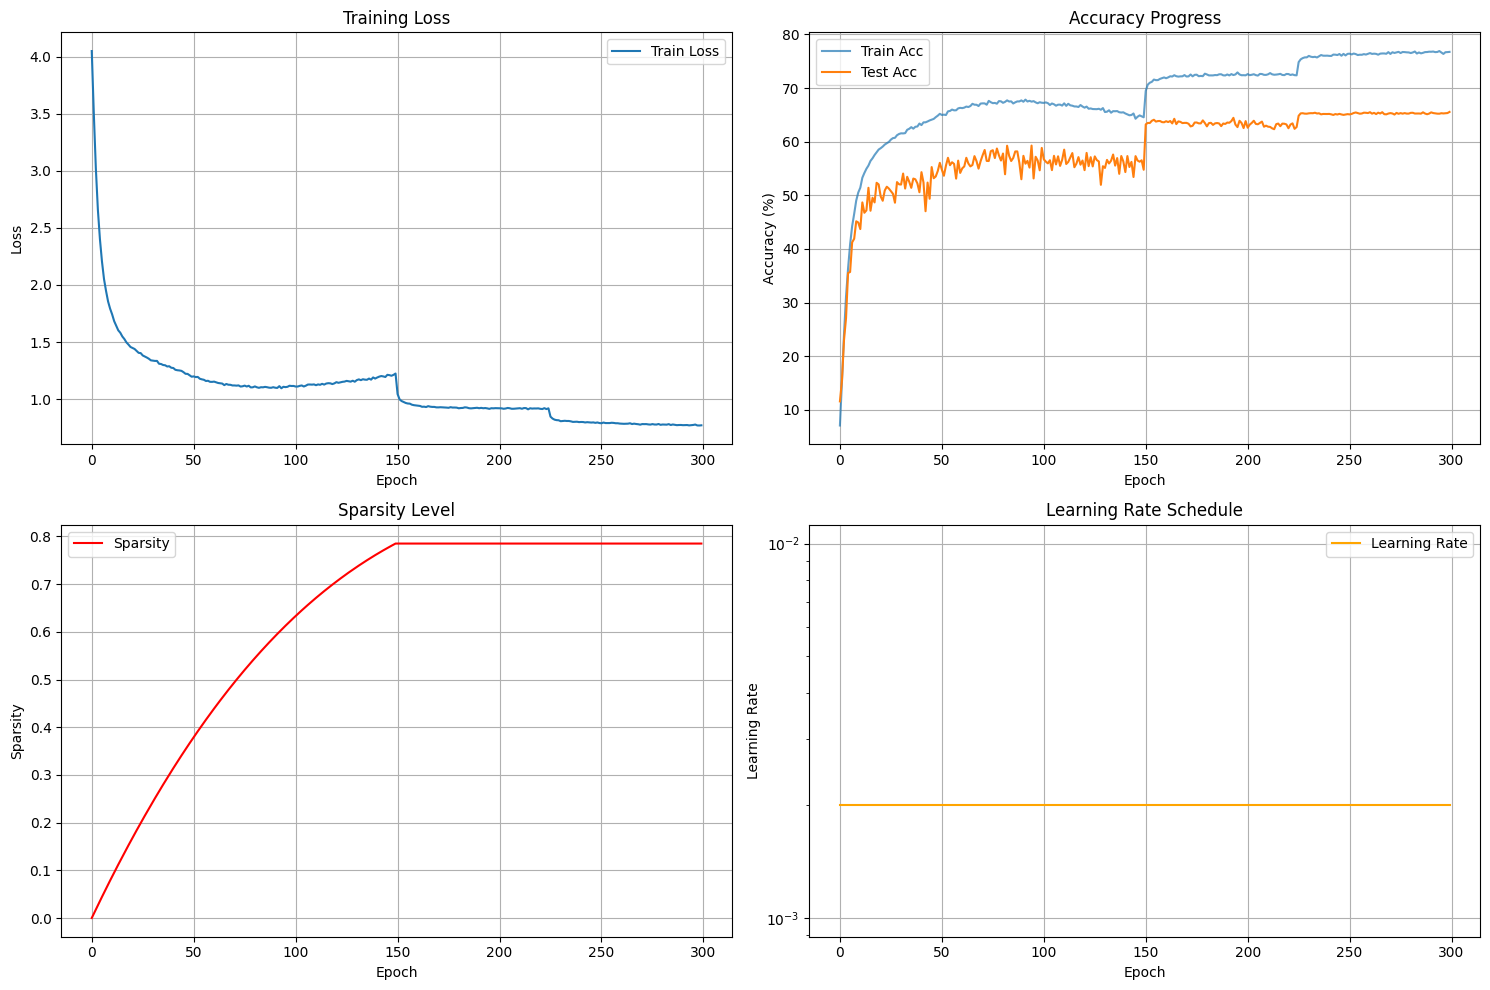

Model saved as ./models/resnet20_cifar100_map_final.pth


In [17]:
# --- Full MAP training cell (300 epochs) — mirrors MAP_Implementation.ipynb ---
# WARNING: This is a long-running cell (~50-60 min on GPU). Run it when you are ready.
print("Starting full MAP training (300 epochs) — CIFAR-100")
print("This will take a long time on a single GPU. Consider enabling checkpointing or running for fewer epochs first.")
print("=" * 60)

# Reset model and create fresh MAP-pruner + trainer (so this run is standalone)
full_model = ResNet20(num_classes=100).to(device)
full_pruner = MAPPruner(full_model, target_sparsity=0.9, start_epoch=0, end_epoch=300)
full_trainer = MAPTrainer(full_model, full_pruner, train_loader, test_loader, device)

# Run full training
full_trainer.train(epochs=300)

print(f"\nFull training completed!")
print(f"Best test accuracy: {full_trainer.best_acc:.2f}%")
print(f"Final sparsity: {full_trainer.sparsity_levels[-1]:.3f}")

# Plot progress
full_trainer.plot_training_progress()

# Save the trained model and metadata — similar to MAP_Implementation
save_path = './models/resnet20_cifar100_map_final.pth'
torch.save({
    'model_state_dict': full_trainer.best_model_state,
    'pruner_target_sparsity': full_pruner.target_sparsity,
    'training_history': {
        'train_losses': full_trainer.train_losses,
        'train_accuracies': full_trainer.train_accuracies,
        'test_accuracies': full_trainer.test_accuracies,
        'sparsity_levels': full_trainer.sparsity_levels
    }
}, save_path)
print(f"Model saved as {save_path}")

In [15]:
# Reinitialize base ResNet-20 (avoid double-conversion if MAP layers already applied)
model = ResNet20(num_classes=100).to(device)
print('Reinitialized model and moved to', device)


Reinitialized model and moved to cuda
